---
# 🐔 La Poule Qui Chante
### Étude de marché international — Poulets Agriculture Biologique
#### Notebook 2 — ACP, Clustering et Recommandations
---


## Contexte

Ce notebook fait directement suite au **Notebook 1** (préparation et nettoyage des données).

On repart du fichier `P11_dataset_final_pour_acp.csv` exporté à la fin du Notebook 1 : **137 pays × 11 variables**.

**Étapes de ce notebook :**
- ACP : réduire les variables en quelques axes synthétiques
- Clustering (CAH puis K-Means) : regrouper les pays par profil similaire
- Recommandation : identifier les pays prioritaires pour l'export de poulet bio


---
## 1) Import des librairies


In [3]:
# Importation de pandas — manipulation des tableaux de données
import pandas as pd

# Importation de numpy — calculs numériques
import numpy as np

# Importation des outils pour l'ACP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Importation des outils pour le clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Importation des outils graphiques
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from math import pi

# Style graphique uniforme pour tout le notebook
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

print('✅ Librairies chargées avec succès')

✅ Librairies chargées avec succès


---
## 2) Chargement des données

On charge le fichier exporté par le Notebook 1.
- `index_col=0` : la première colonne (`country`) devient l'index — chaque ligne est identifiée par le nom du pays
- `decimal='.'` : on s'assure que les nombres sont bien lus avec un point comme séparateur décimal


In [4]:
# Chargement du fichier produit par le Notebook 1
df = pd.read_csv('P11_dataset_final_pour_acp.csv', decimal='.', index_col=0)

print('Dimensions du dataset :', df.shape)
df.head()


Dimensions du dataset : (137, 11)


,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
country,,,,,,,,,,,
Afghanistan,36296113.0,74.668889,525.469771,25.250,-1.607798,66.0,0.00,5.0,0.771432,0.000000,0.798984
Albanie,2884169.0,-7.831734,4614.047969,59.383,0.000207,87.7,0.05,85.0,4.507364,0.000000,13.175372
Émirats arabes unis,9487203.0,202.712678,42340.591716,86.248,0.629879,83.5,1.10,147.0,5.059447,9.908084,45.640427
Argentine,43937140.0,19.165181,14532.500931,91.749,0.013932,66.7,3.04,182.0,49.183902,4.711276,0.182078
Arménie,2944791.0,-4.065688,3869.053739,63.103,-0.342741,80.2,0.09,54.0,3.735409,0.000000,11.885394


In [5]:
# Aperçu des dernières lignes
df.tail()


,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
country,,,,,,,,,,,
Vanuatu,285510.0,54.353091,3159.860558,25.163,0.104364,73.9,7.96,40.0,3.502504,0.000000,14.010017
Samoa,195352.0,11.979089,4307.593820,18.452,0.689320,70.7,37.60,217.0,0.000000,0.000000,87.022401
Afrique du Sud,57009756.0,26.779324,6618.335083,65.850,0.045187,77.3,0.02,143.0,29.240609,1.105074,9.016001
Zambie,16853599.0,61.805776,1483.465773,42.976,-0.386301,78.3,0.00,11.0,2.907391,0.059335,0.712014
Zimbabwe,14236595.0,19.821761,3448.086991,32.237,-1.243019,52.8,0.00,16.0,4.846665,0.000000,0.421449


In [6]:
# Vérification : types de données et valeurs manquantes
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 137 entries, Afghanistan to Zimbabwe
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   pop_2017                         137 non-null    float64
 1   population_growth_2000_2017_pct  137 non-null    float64
 2   gdp_per_capita_2017_usd          137 non-null    float64
 3   urban_pop_2017_pct               137 non-null    float64
 4   governance_index_mean            137 non-null    float64
 5   trade_freedom_2017               137 non-null    float64
 6   organic_agri_share_pct           137 non-null    float64
 7   dispo_volaille_kcal_jour         137 non-null    float64
 8   production_volaille_per_million  137 non-null    float64
 9   export_volaille_per_million      137 non-null    float64
 10  import_volaille_per_million      137 non-null    float64
dtypes: float64(11)
memory usage: 12.8+ KB


In [7]:
# Statistiques descriptives
df.describe().T


,count,mean,std,min,25%,50%,75%,max
pop_2017,137.0,5.141627e+07,1.704536e+08,71458.000000,4.106769e+06,1.117520e+07,3.673210e+07,1.421022e+09
population_growth_2000_2017_pct,137.0,2.850938e+01,2.961606e+01,-18.745151,8.495167e+00,2.357315e+01,4.556874e+01,2.027127e+02
gdp_per_capita_2017_usd,137.0,1.490335e+04,2.001461e+04,470.938563,1.964299e+03,5.955297e+03,1.863199e+04,1.101932e+05
urban_pop_2017_pct,137.0,6.008496e+01,2.196048e+01,16.350000,4.294500e+01,6.130000e+01,7.856000e+01,1.000000e+02
governance_index_mean,137.0,5.230346e-02,8.223986e-01,-1.607798,-5.740071e-01,-1.721696e-01,6.506532e-01,1.835300e+00
trade_freedom_2017,137.0,7.790584e+01,9.142771e+00,50.600000,7.060000e+01,8.000000e+01,8.700000e+01,9.000000e+01
organic_agri_share_pct,137.0,3.044015e+00,5.572723e+00,0.000000,1.000000e-01,5.000000e-01,3.360000e+00,3.760000e+01
dispo_volaille_kcal_jour,137.0,7.084672e+01,5.331329e+01,0.000000,2.200000e+01,6.500000e+01,1.030000e+02,2.340000e+02
production_volaille_per_million,137.0,1.813589e+01,1.756414e+01,0.000000,3.167711e+00,1.389302e+01,2.698847e+01,7.629932e+01
export_volaille_per_million,137.0,3.656253e+00,9.875665e+00,0.000000,0.000000e+00,8.934271e-02,3.016134e+00,8.330716e+01


Toutes les colonnes sont numériques et il n'y a **aucune valeur manquante** — le dataset est prêt pour l'ACP.


---
## 3) Préparation des données

L'ACP a besoin de deux choses :
1. Une **matrice de nombres** `X` (sans texte, sans index)
2. Des variables **à la même échelle** — sinon les variables avec de grandes valeurs (ex : PIB en milliers de $) domineraient l'analyse


### 3.a — Séparation des données


In [8]:
# X : la matrice des valeurs numériques
X = df.values

# On garde les noms des pays et des variables pour les afficher dans les graphiques
names = df.index
features = df.columns

print('Type de X :', type(X))
print('Taille de X :', X.shape, '— (pays × variables)')
print()
print('Pays (5 premiers) :', list(names[:5]))
print('Variables :', list(features))


Type de X : <class 'numpy.ndarray'>
Taille de X : (137, 11) — (pays × variables)

Pays (5 premiers) : ['Afghanistan', 'Albanie', 'Émirats arabes unis', 'Argentine', 'Arménie']
Variables : ['pop_2017', 'population_growth_2000_2017_pct', 'gdp_per_capita_2017_usd', 'urban_pop_2017_pct', 'governance_index_mean', 'trade_freedom_2017', 'organic_agri_share_pct', 'dispo_volaille_kcal_jour', 'production_volaille_per_million', 'export_volaille_per_million', 'import_volaille_per_million']


### 3.b — Centrage et réduction (standardisation)

On transforme chaque variable pour qu'elle ait :
- une **moyenne = 0**
- un **écart-type = 1**

Cela permet à toutes les variables de contribuer de façon équilibrée à l'ACP,
quelle que soit leur unité d'origine (%, USD, kcal...).

#### Pourquoi StandardScaler plutôt qu'une autre méthode ?

| Méthode | Principe | Quand l'utiliser |
|---|---|---|
| **StandardScaler** ✅ | Moyenne = 0, écart-type = 1 | **ACP, clustering** — variables d'unités différentes |
| MinMaxScaler | Ramène entre [0, 1] | Réseaux de neurones — sensible aux outliers |
| RobustScaler | Utilise la médiane et l'IQR | Données avec beaucoup d'outliers |

**Choix retenu : StandardScaler** — c'est le standard pour l'ACP car il suppose que chaque variable contribue de façon égale.
MinMaxScaler serait biaisé par les valeurs extrêmes (ex : un PIB très élevé aux Émirats écraserait les autres pays sur cet axe).

In [9]:
# On instancie l'outil de standardisation
scaler = StandardScaler()

# On l'entraîne sur nos données
scaler.fit(X)

# On transforme les données
X_scaled = scaler.transform(X)

# Vérification : moyenne ≈ 0, écart-type ≈ 1 pour chaque colonne
verif = pd.DataFrame(X_scaled).describe().round(2)
print('Vérification après standardisation :')
verif.loc[['mean', 'std'], :]


Vérification après standardisation :


,0,1,2,3,4,5,6,7,8,9,10
mean,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


---
## 4) ACP — Analyse en Composantes Principales

L'ACP transforme nos 11 variables en **composantes principales** (F1, F2, F3...).
Chaque composante est une combinaison de toutes les variables, et capture une partie de l'information totale.

L'objectif : résumer l'essentiel de l'information en **quelques axes** plus faciles à analyser et à visualiser.


### 4.a — Lancement de l'ACP


In [10]:
# On travaille sur 6 composantes
n_components = 6

# On instancie l'ACP
pca = PCA(n_components=n_components)

# On l'entraîne sur les données standardisées
pca.fit(X_scaled)

print('✅ ACP réalisée sur', n_components, 'composantes')


✅ ACP réalisée sur 6 composantes


### 4.b — Éboulis des valeurs propres

Ce graphique montre combien d'information (**variance**) chaque composante capture :
- **Barres bleues** → % d'information de chaque composante
- **Courbe rouge** → % cumulé

On cherche le **coude** : le point où la courbe rouge ralentit fortement.
C'est là qu'on s'arrête — les composantes suivantes n'apportent plus grand chose.


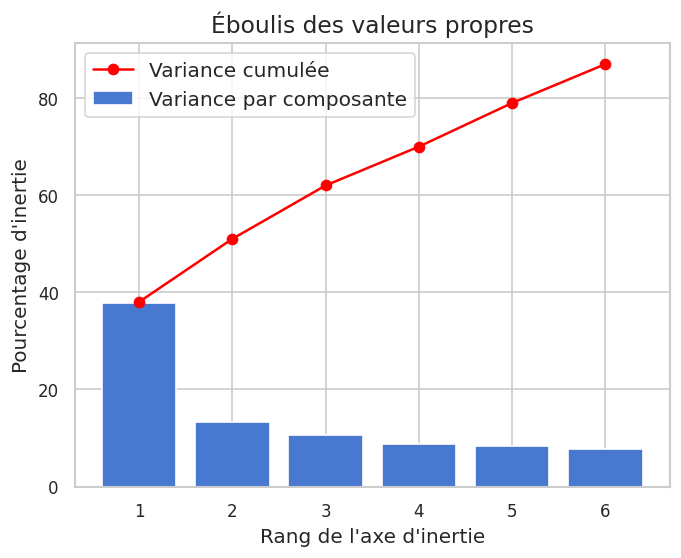

Variance par composante : [37.89, 13.21, 10.67, 8.7, 8.34, 7.82]
Variance cumulée        : [38.0, 51.0, 62.0, 70.0, 79.0, 87.0]


In [11]:
# Variance expliquée par chaque composante (en %)
scree = (pca.explained_variance_ratio_ * 100).round(2)

# Variance cumulée
scree_cum = scree.cumsum().round()

# Numéros des composantes
x_list = range(1, n_components + 1)

# Graphique
plt.bar(x_list, scree, label='Variance par composante')
plt.plot(x_list, scree_cum, c='red', marker='o', label='Variance cumulée')
plt.xlabel("Rang de l'axe d'inertie")
plt.ylabel("Pourcentage d'inertie")
plt.title("Éboulis des valeurs propres")
plt.legend()
plt.show()

print('Variance par composante :', scree.tolist())
print('Variance cumulée        :', scree_cum.tolist())


**Lecture :**
- F1 capte ~38 % de la variance, F2 ~13 %, F3 ~11 %
- Les **4 premières composantes captent ~70 %** de l'information totale
- On retient **4 composantes** pour la suite — bon compromis entre simplification et conservation de l'information


### 4.c — Contributions des variables aux composantes

Les **loadings** (coordonnées brutes) indiquent le sens de la corrélation entre variable et composante.
La **contribution** d'une variable à une composante se calcule comme : `loading² / somme(loadings²) × 100`.
Elle exprime la part d'information que la variable apporte à cet axe.

In [12]:
# Récupération des composantes
pcs = pca.components_

# Mise en forme dans un tableau lisible
pcs = pd.DataFrame(pcs)
pcs.columns = features
pcs.index = [f'F{i}' for i in x_list]

print('Contribution des variables à chaque composante :')
pcs.round(2)


Contribution des variables à chaque composante :


,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
F1,-0.06,-0.22,0.38,0.37,0.43,0.33,0.21,0.34,0.33,0.26,0.18
F2,-0.27,0.14,0.11,-0.15,0.16,-0.05,0.52,-0.16,-0.50,-0.06,0.55
F3,-0.27,0.51,-0.05,0.25,-0.16,-0.35,-0.31,0.44,0.15,-0.00,0.38
F4,0.83,-0.12,-0.09,-0.02,-0.02,-0.31,0.15,0.20,-0.01,0.07,0.34
F5,0.35,0.50,0.48,0.23,0.22,0.15,-0.16,-0.10,-0.25,-0.38,-0.19
F6,0.10,0.29,0.14,-0.05,0.01,0.03,-0.23,-0.41,-0.04,0.81,0.08


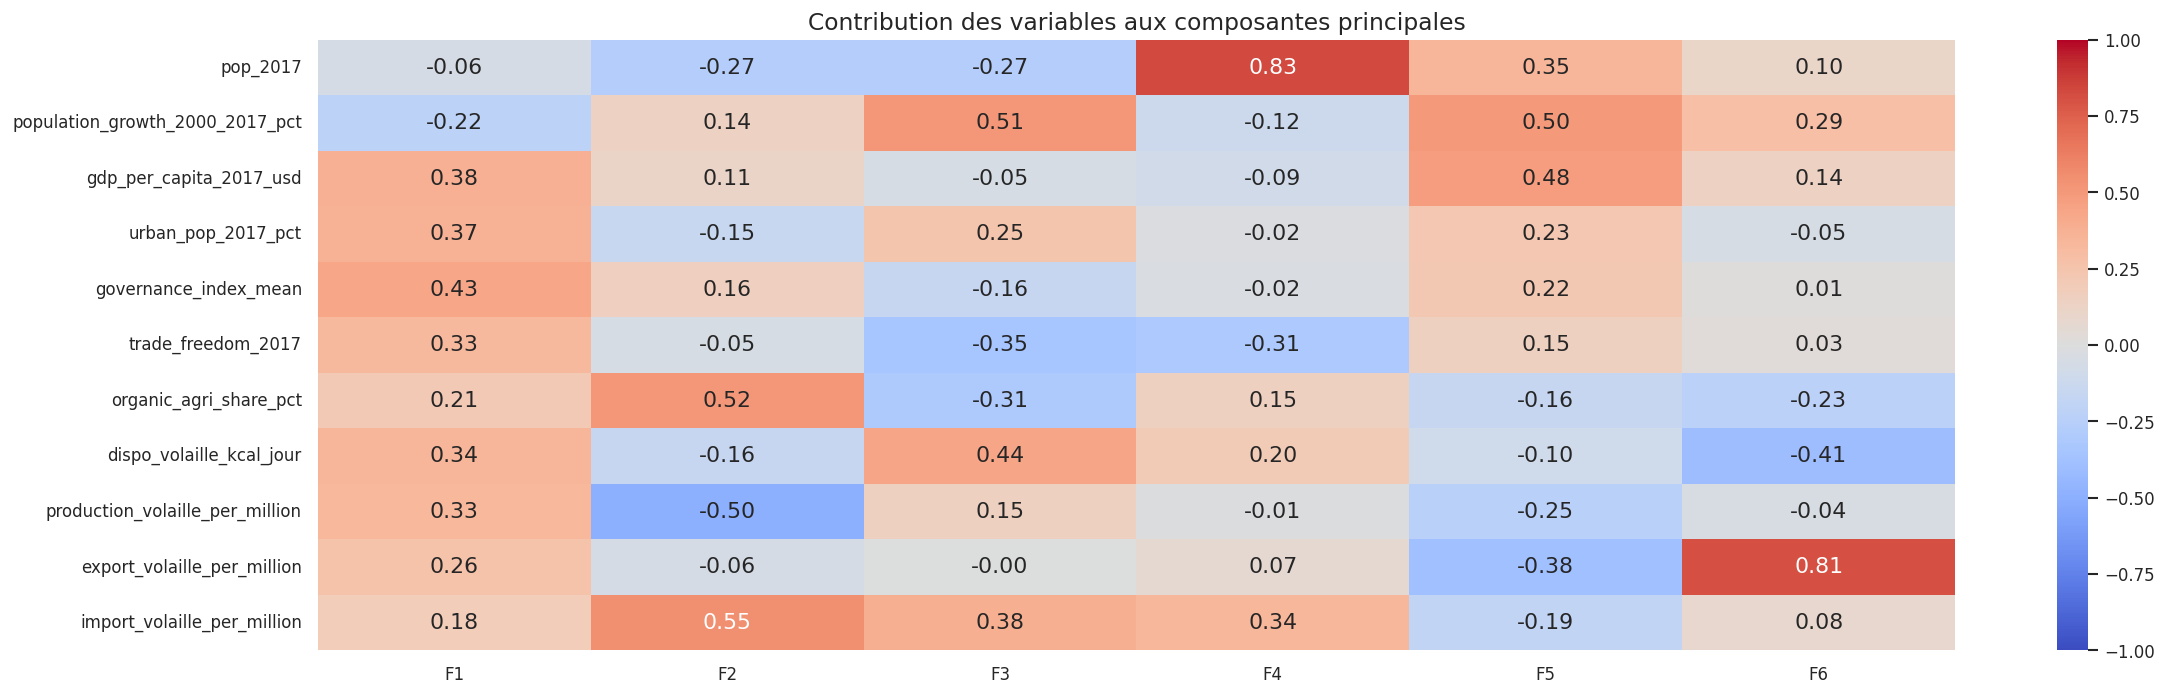

In [13]:
# Heatmap des contributions — plus visuel
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap='coolwarm', fmt='0.2f')
plt.title('Contribution des variables aux composantes principales')
plt.tight_layout()
plt.show()


In [14]:
# Contributions des variables en pourcentage par composante
# Formule : contribution = loading² / somme(loadings²) par composante × 100
contributions = pcs.copy()
for col in contributions.columns:
    contributions[col] = contributions[col] ** 2
contributions = contributions.div(contributions.sum(axis=1), axis=0) * 100

print('Contribution des variables (% d\'information apportée à chaque axe) :')
contributions.round(1)

Contribution des variables (% d'information apportée à chaque axe) :


,pop_2017,population_growth_2000_2017_pct,gdp_per_capita_2017_usd,urban_pop_2017_pct,governance_index_mean,trade_freedom_2017,organic_agri_share_pct,dispo_volaille_kcal_jour,production_volaille_per_million,export_volaille_per_million,import_volaille_per_million
F1,0.4,4.8,14.5,13.8,18.6,10.6,4.5,11.8,10.9,6.7,3.3
F2,7.1,2.0,1.3,2.2,2.6,0.3,26.6,2.5,25.1,0.4,29.9
F3,7.1,26.0,0.3,6.1,2.5,12.1,9.4,19.5,2.2,0.0,14.7
F4,69.4,1.5,0.8,0.0,0.1,9.9,2.2,3.9,0.0,0.4,11.8
F5,12.3,24.5,22.8,5.2,4.9,2.4,2.6,0.9,6.1,14.7,3.6
F6,1.1,8.2,1.9,0.3,0.0,0.1,5.3,16.6,0.2,65.6,0.7


**Lecture des contributions :**
- Une contribution élevée signifie que la variable tire fortement cet axe dans sa direction.
- On identifie les **variables structurantes** de chaque composante — utile pour interpréter les clusters.

**Lecture :**
- **F1** = axe de développement économique : PIB, urbanisation, gouvernance, liberté du commerce
- **F2** = axe import/production : oppose les pays dépendants des imports à ceux qui produisent
- **F3** = axe de dynamique démographique : croissance de population
- **F4** = axe d'échanges commerciaux : export de volaille


---
## 5) Cercle des corrélations

Le cercle des corrélations visualise les liens entre les variables originales et les axes de l'ACP.

**Comment le lire :**
- Flèche **longue** (proche du bord) → variable bien représentée sur ce plan
- Deux flèches **dans le même sens** → variables corrélées positivement
- Deux flèches **en sens opposé** → variables corrélées négativement
- Deux flèches **perpendiculaires** → variables indépendantes


In [15]:
# Fonction pour afficher le cercle des corrélations
def cercle_correlations(pca, axes, features):
    x, y = axes

    fig, ax = plt.subplots(figsize=(10, 9))

    # Une flèche par variable
    for i in range(pca.components_.shape[1]):
        ax.arrow(0, 0,
                 pca.components_[x, i],
                 pca.components_[y, i],
                 head_width=0.07, head_length=0.07, width=0.02)
        plt.text(pca.components_[x, i] + 0.05,
                 pca.components_[y, i] + 0.05,
                 features[i])

    # Lignes de référence
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Noms des axes avec % de variance
    plt.xlabel('F{} ({}%)'.format(x + 1, round(100 * pca.explained_variance_ratio_[x], 1)))
    plt.ylabel('F{} ({}%)'.format(y + 1, round(100 * pca.explained_variance_ratio_[y], 1)))
    plt.title('Cercle des corrélations (F{} et F{})'.format(x + 1, y + 1))

    # Le cercle unité
    angles = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(angles), np.sin(angles))
    plt.axis('equal')
    plt.tight_layout()
    plt.show()


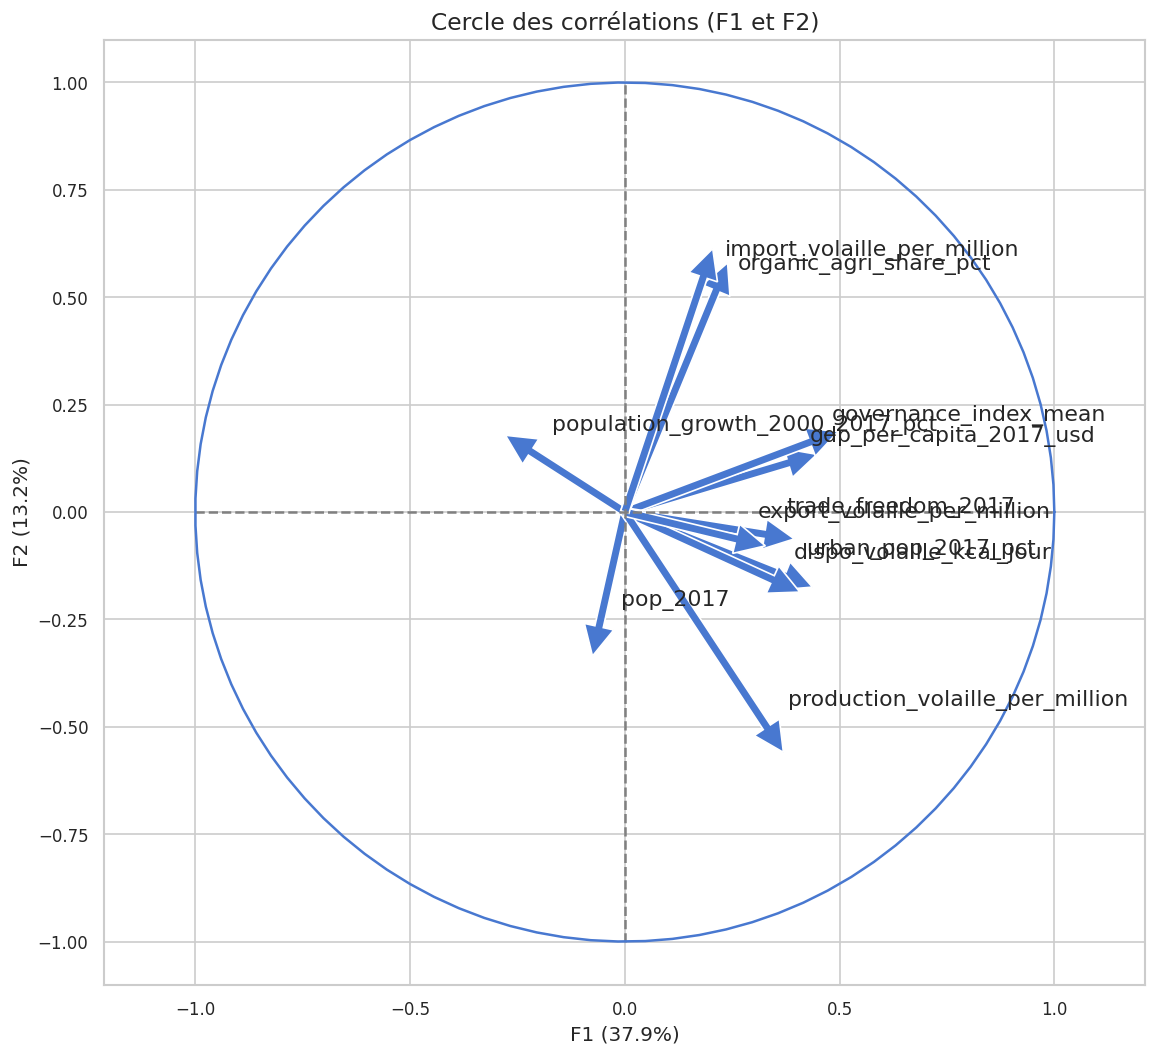

In [16]:
# Cercle F1 - F2 : les deux axes principaux
cercle_correlations(pca, (0, 1), features)


**Lecture F1–F2 :**
- Sur F1 (axe horizontal) : PIB, urbanisation, gouvernance et liberté du commerce pointent dans le même sens
  → ces variables sont fortement corrélées entre elles (pays développés = bonne gouvernance = marché ouvert)
- Sur F2 (axe vertical) : `import_volaille_per_million` pointe vers le haut,
  `production_volaille_per_million` vers le bas → les pays qui importent peu produisent beaucoup, et vice versa
- `organic_agri_share_pct` pointe vers le haut-droite → le bio est associé aux pays développés et importateurs


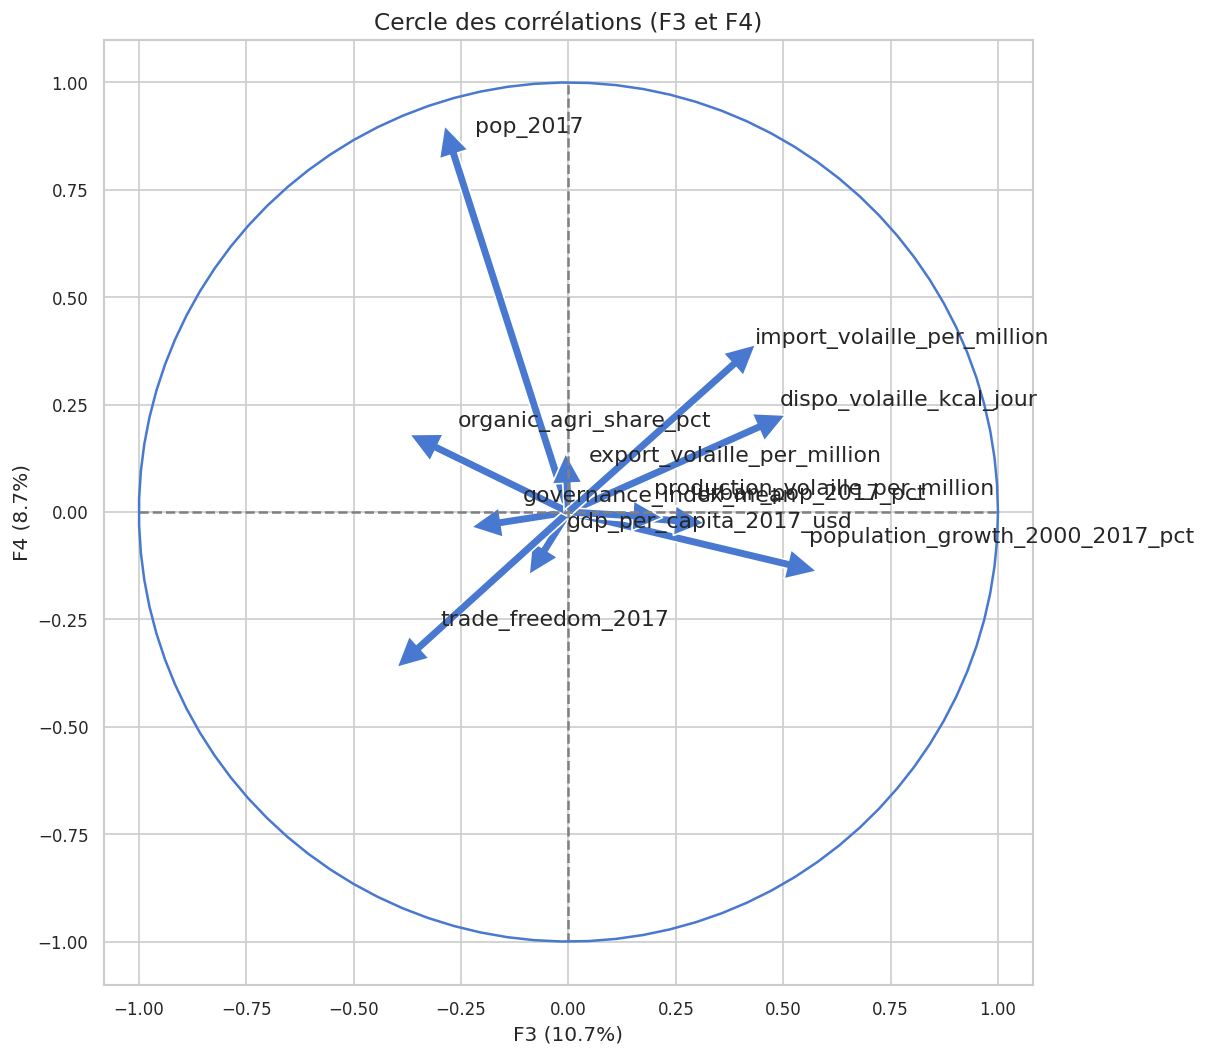

In [17]:
# Cercle F3 - F4 : axes secondaires
cercle_correlations(pca, (2, 3), features)


**Lecture F3–F4 :**
- F3 est dominé par `population_growth_2000_2017_pct` → axe de dynamique démographique
- F4 est dominé par `export_volaille_per_million` → axe de spécialisation à l'export
- Ces deux axes apportent une information complémentaire (~21 % de variance supplémentaire)
  mais moins structurante pour notre objectif d'identification de marchés cibles


---
## 6) Projection des individus

On projette chaque pays dans l'espace ACP.
Deux pays proches sur ce graphique ont des **profils similaires**.
C'est la visualisation qui justifie de faire un clustering.


In [18]:
# Calcul des coordonnées de chaque pays dans l'espace ACP
X_proj = pca.transform(X_scaled)

print('Coordonnées calculées pour', X_proj.shape[0], 'pays sur', X_proj.shape[1], 'axes')


Coordonnées calculées pour 137 pays sur 6 axes


In [19]:
# Fonction pour afficher la projection des pays
def projection_pays(X_proj, axes, pca=None, labels=None, clusters=None, figsize=(10, 8)):
    x, y = axes

    fig, ax = plt.subplots(figsize=figsize)

    sns.scatterplot(x=X_proj[:, x], y=X_proj[:, y], hue=clusters, ax=ax)

    # Noms des axes avec % de variance
    if pca is not None:
        ax.set_xlabel('F{} ({}%)'.format(x + 1, round(100 * pca.explained_variance_ratio_[x])))
        ax.set_ylabel('F{} ({}%)'.format(y + 1, round(100 * pca.explained_variance_ratio_[y])))
    else:
        ax.set_xlabel(f'F{x + 1}')
        ax.set_ylabel(f'F{y + 1}')

    # Limites et lignes de référence
    x_max = np.abs(X_proj[:, x]).max() * 1.1
    y_max = np.abs(X_proj[:, y]).max() * 1.1
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.5)
    plt.plot([0, 0], [-y_max, y_max], color='grey', alpha=0.5)

    # Noms des pays si fournis
    if labels is not None:
        for i, (px, py) in enumerate(X_proj[:, [x, y]]):
            plt.text(px, py + 0.05, labels[i], fontsize=7, ha='center')

    plt.title(f'Projection des individus (F{x + 1} et F{y + 1})')
    plt.tight_layout()
    plt.show()


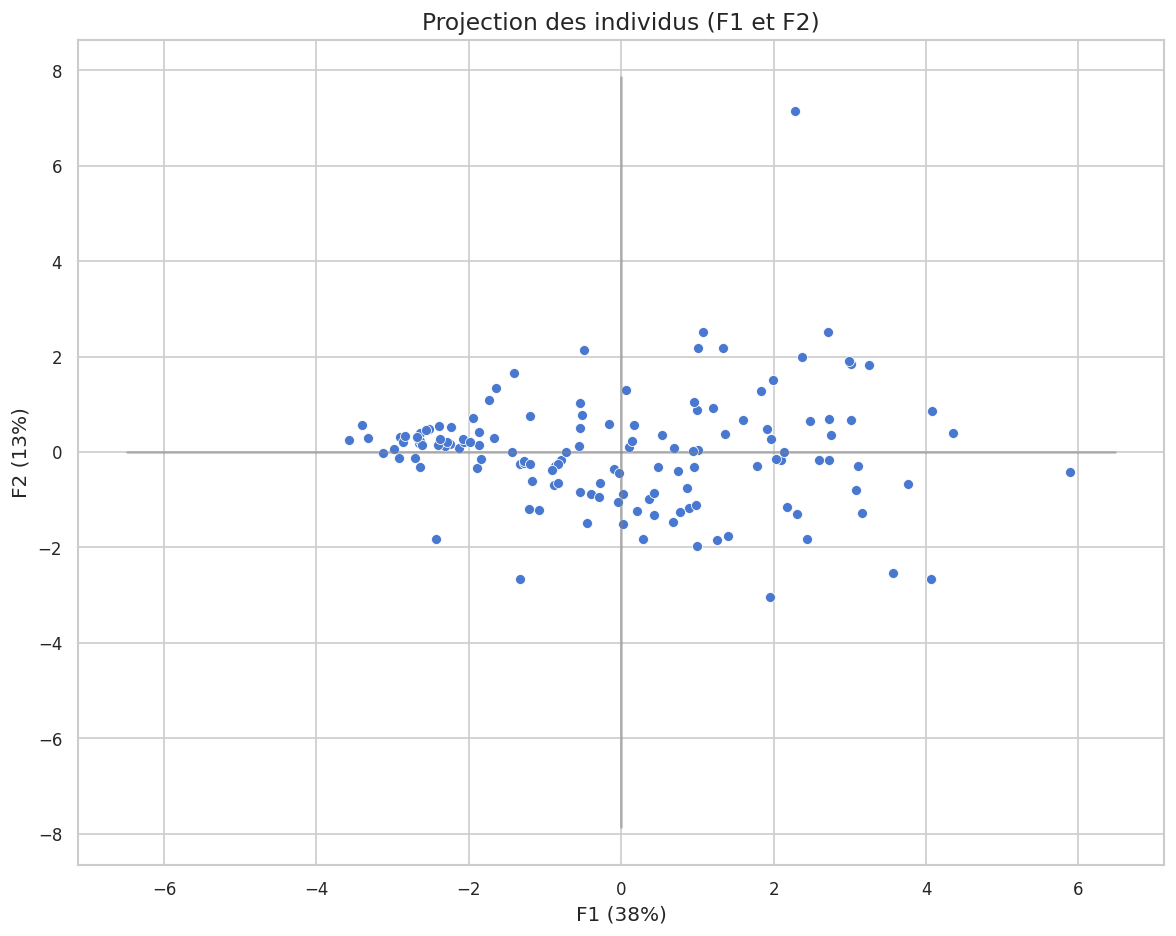

In [20]:
# Projection simple — sans noms, pour voir la structure globale
projection_pays(X_proj, [0, 1], pca=pca)


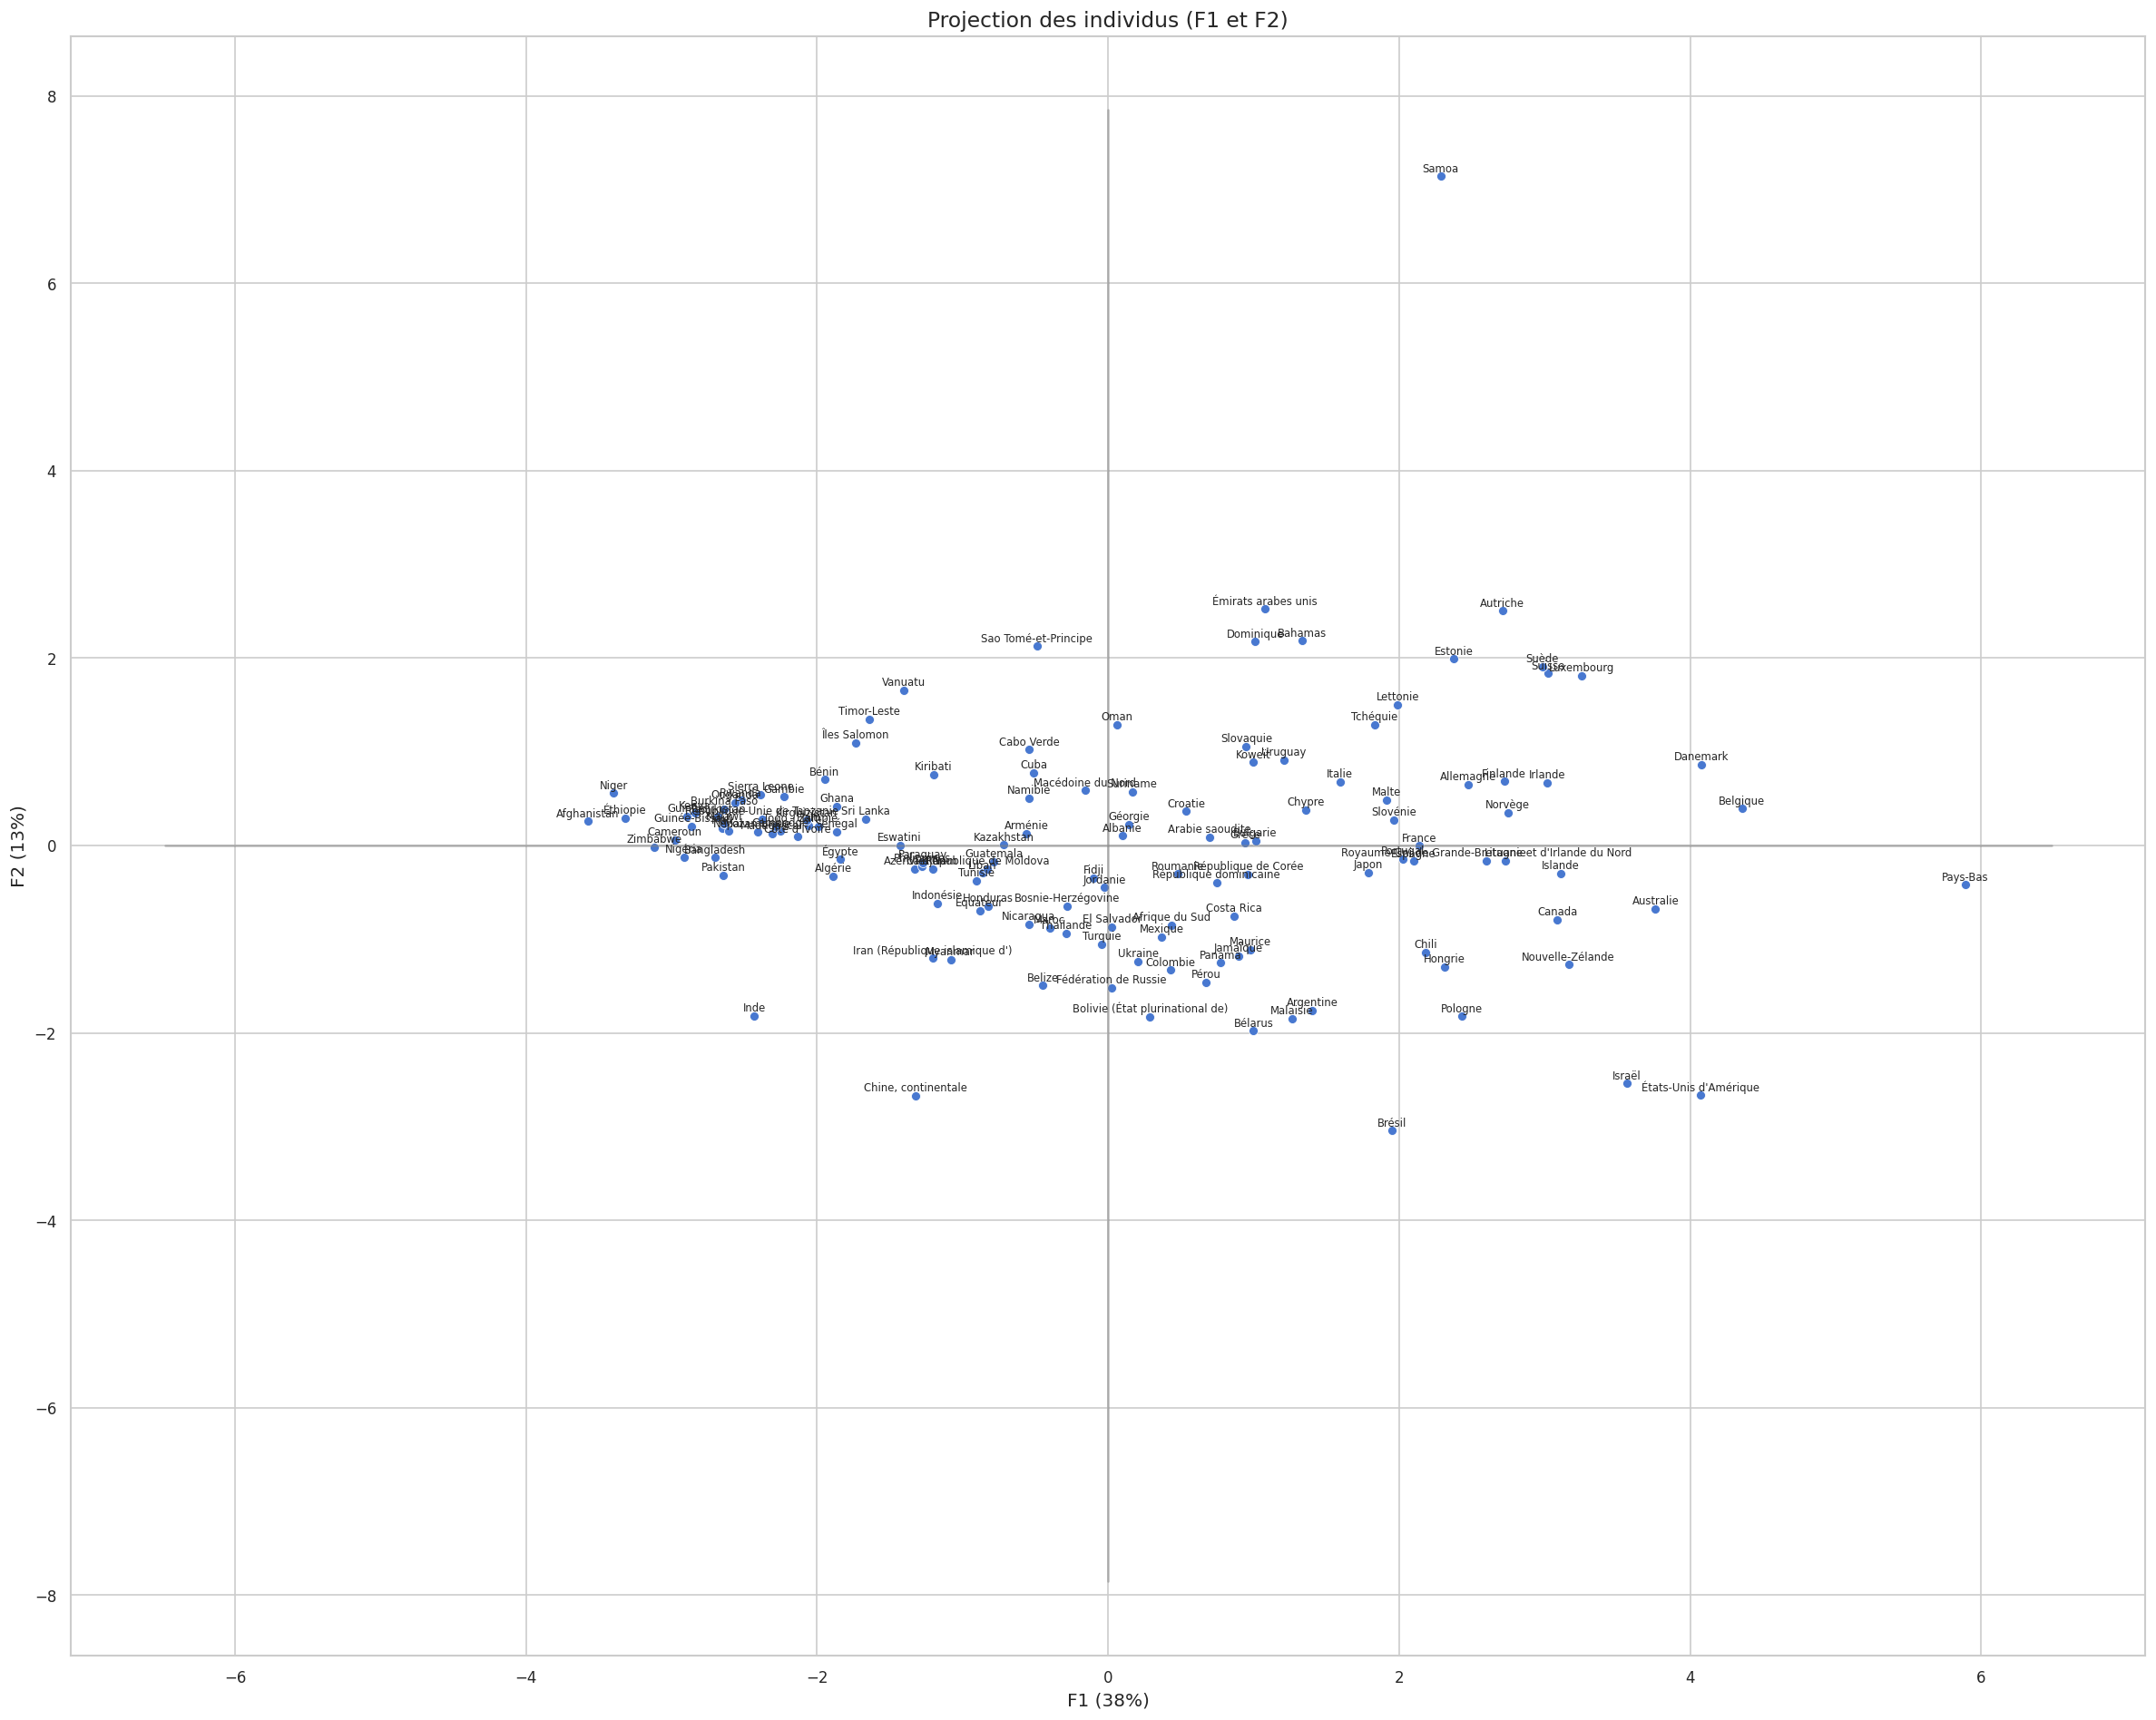

In [21]:
# Projection avec les noms des pays
projection_pays(X_proj, [0, 1], pca=pca, labels=names, figsize=(20, 16))


**Lecture :**
- Pays à **droite** (F1 positif) → pays développés, urbanisés, bonne gouvernance (ex : Pays-Bas, Suisse)
- Pays à **gauche** (F1 négatif) → pays moins développés, plus ruraux (ex : Niger, Éthiopie)
- Pays **en haut** (F2 positif) → forte dépendance aux importations de volaille (ex : Émirats, Samoa)
- Pays **en bas** (F2 négatif) → gros producteurs de volaille (ex : Brésil, États-Unis, Argentine)

Cette structure suggère l'existence de **groupes de pays distincts** → on passe au clustering.


---
## 7) Clustering

On regroupe les pays aux profils similaires en **clusters**.

On utilise les **4 premières composantes ACP** (non corrélées, ~70 % de l'info)
plutôt que les données brutes — les données brutes sont corrélées entre elles
et fausseraient les distances entre pays.

Deux méthodes sont appliquées et comparées :
- **CAH** : explore la structure hiérarchique des données
- **K-Means** : produit une segmentation opérationnelle équilibrée


In [22]:
# Matrice de clustering : 4 premières composantes ACP
n_comp_clust = 4
X_clust = X_proj[:, :n_comp_clust]

print('Matrice pour le clustering :', X_clust.shape, '(pays × composantes retenues)')


Matrice pour le clustering : (137, 4) (pays × composantes retenues)


### 7.a — Choisir le nombre de clusters optimal

Deux outils pour trouver le bon nombre k :
- **Diagramme du coude** : on cherche le k où l'inertie arrête de baisser fortement
- **Coefficient de silhouette** : mesure la qualité de la séparation entre clusters (entre -1 et 1, plus c'est haut, mieux c'est)


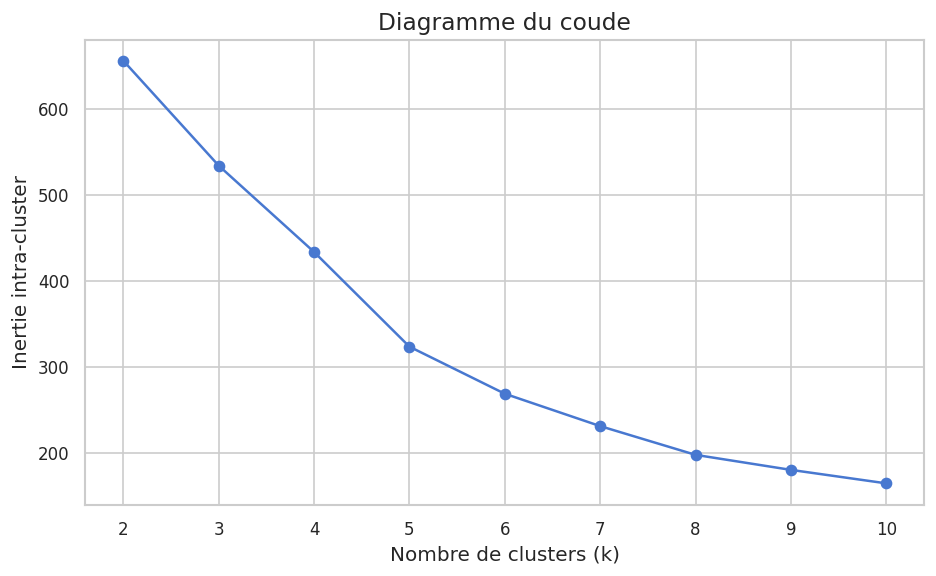

In [23]:
# Diagramme du coude
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie intra-cluster')
plt.title('Diagramme du coude')
plt.tight_layout()
plt.show()


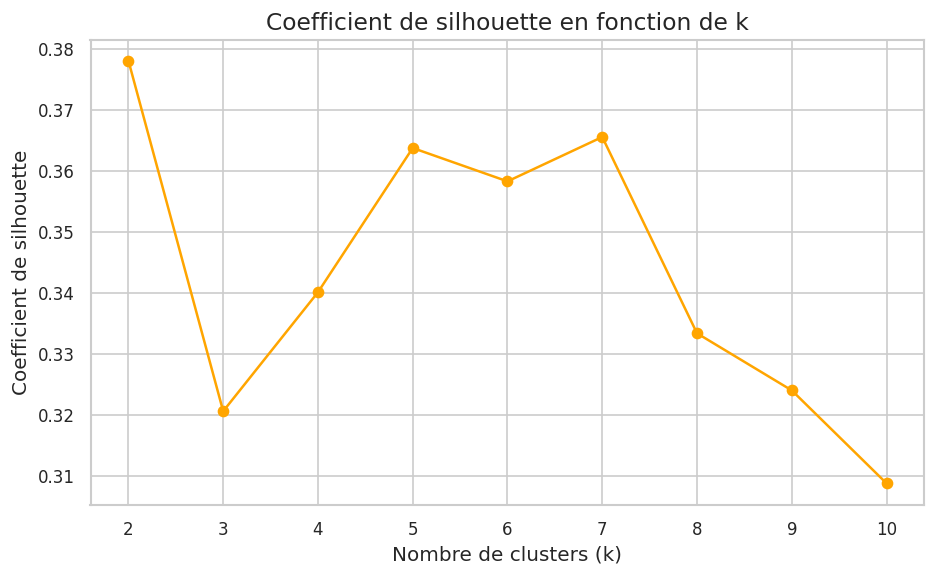

k = 2  →  silhouette = 0.378
k = 3  →  silhouette = 0.321
k = 4  →  silhouette = 0.340
k = 5  →  silhouette = 0.364
k = 6  →  silhouette = 0.358
k = 7  →  silhouette = 0.366
k = 8  →  silhouette = 0.333
k = 9  →  silhouette = 0.324
k = 10  →  silhouette = 0.309


In [24]:
# Coefficient de silhouette
silhouette_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_clust)
    score = silhouette_score(X_clust, labels_k)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker='o', color='orange')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Coefficient de silhouette')
plt.title('Coefficient de silhouette en fonction de k')
plt.tight_layout()
plt.show()

for k, s in zip(K_range, silhouette_scores):
    print(f'k = {k}  →  silhouette = {s:.3f}')


**Lecture :**
- Le coude du diagramme est visible à **k = 4** : l'inertie baisse fortement jusqu'à 4, puis ralentit
- Le coefficient de silhouette atteint son maximum à **k = 4** (~0.32) — bonne séparation entre les groupes
- Les deux outils convergent → on retient **4 clusters**


### 7.b — CAH (Classification Ascendante Hiérarchique)


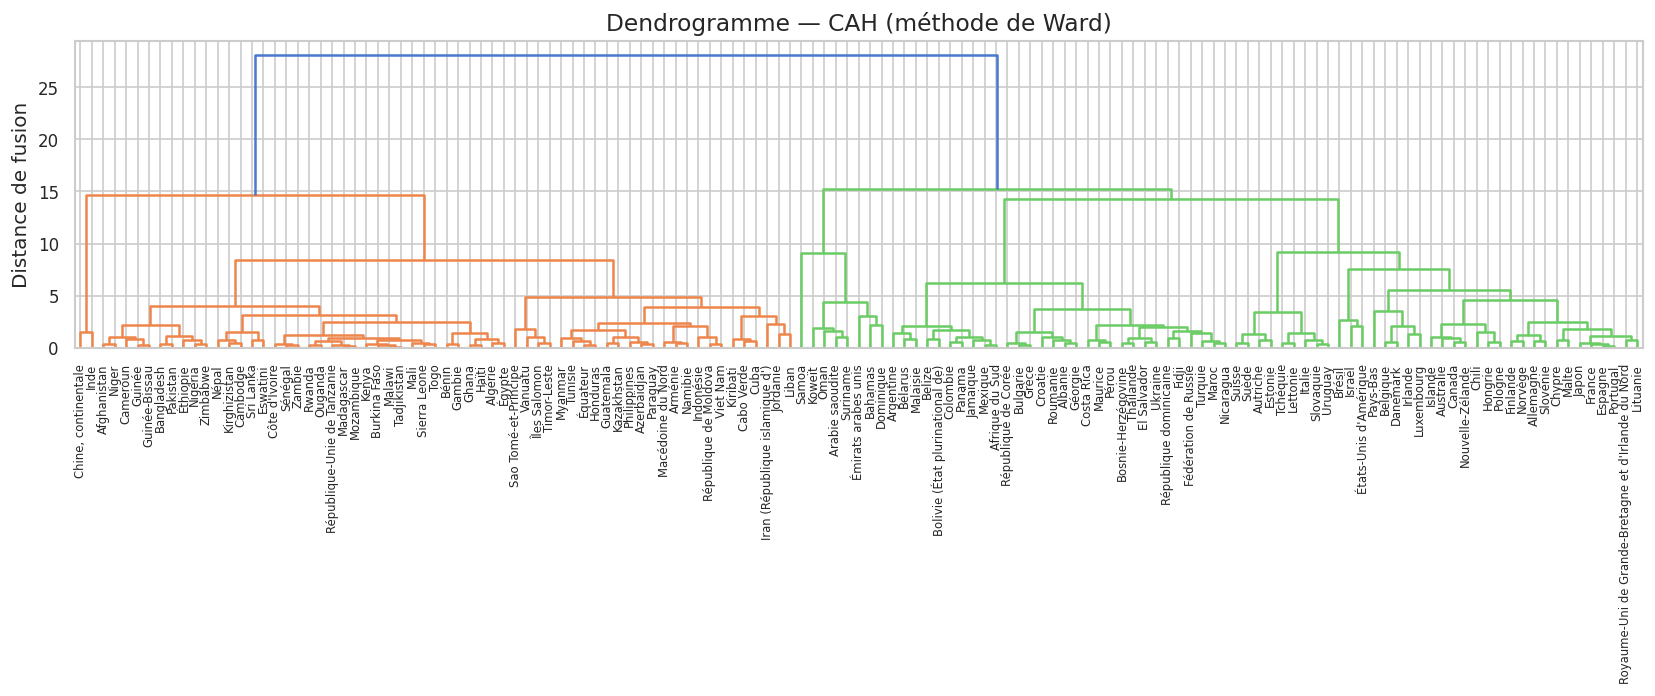

In [25]:
# Calcul de la CAH — méthode de Ward
Z = linkage(X_clust, method='ward')

# Dendrogramme
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=list(names), leaf_rotation=90, leaf_font_size=7)
plt.title('Dendrogramme — CAH (méthode de Ward)')
plt.ylabel('Distance de fusion')
plt.tight_layout()
plt.show()


**Lecture du dendrogramme :**
Les pays proches en bas se ressemblent le plus.
On observe une **rupture nette** autour d'une hauteur de fusion entre 13 et 15,
suivie d'un saut important vers 25.
Cette rupture confirme l'existence de **4 groupes bien distincts**.


In [26]:
# On coupe le dendrogramme pour obtenir 4 clusters
k_cah = 4
labels_cah = fcluster(Z, t=k_cah, criterion='maxclust')

# On ajoute les labels au dataframe
df['cluster_cah'] = labels_cah

print('Répartition des pays par cluster (CAH) :')
print(df['cluster_cah'].value_counts().sort_index())


Répartition des pays par cluster (CAH) :
cluster_cah
1     2
2    61
3     8
4    66
Name: count, dtype: int64


La CAH isole souvent un pays au profil très atypique dans un cluster de taille 1.
Ce n'est pas une erreur — c'est une observation extrême que la méthode détecte.
On le notera pour le comparer avec le résultat du K-Means.


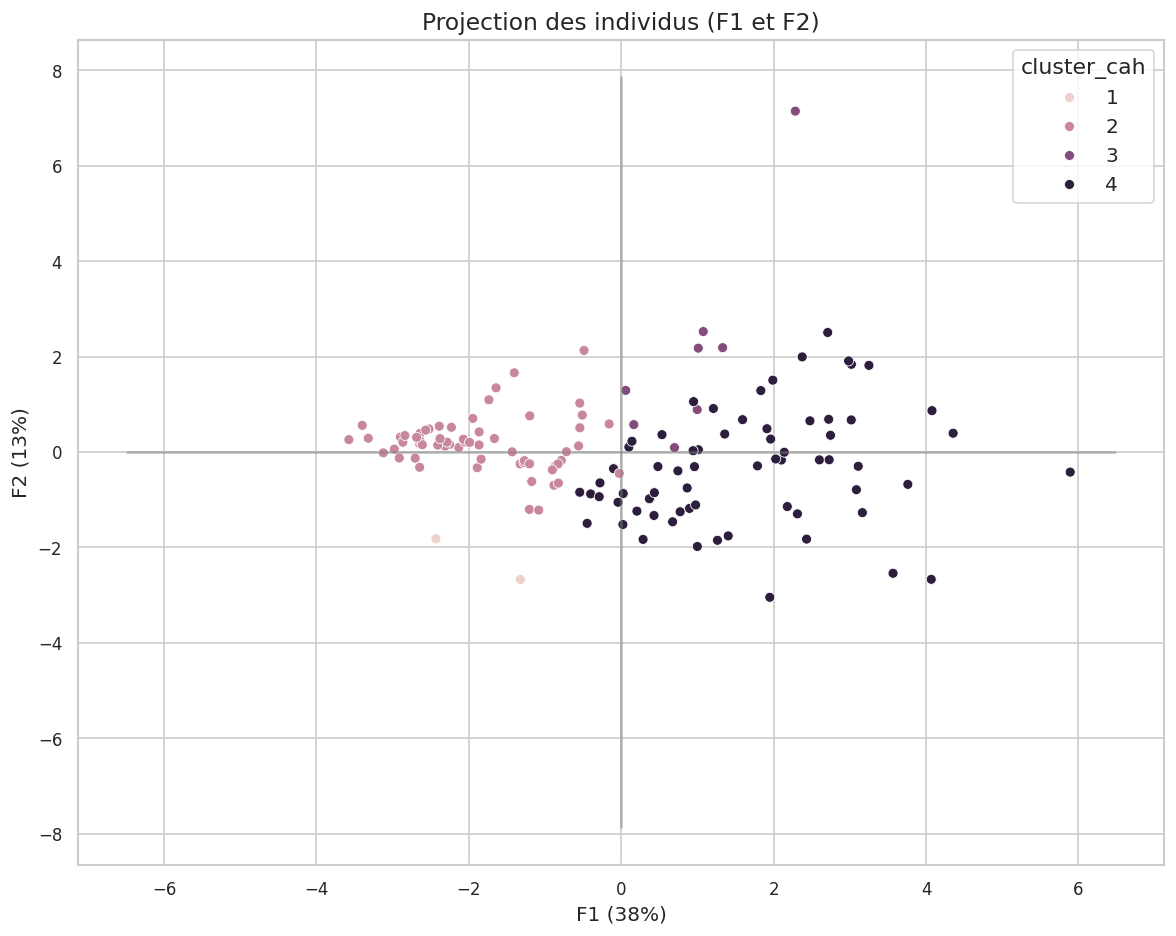

In [27]:
# Projection des clusters CAH sur F1–F2
projection_pays(X_proj, [0, 1], pca=pca, clusters=df['cluster_cah'])


In [28]:
# Vérification : y a-t-il un cluster isolé (pays atypique) ?
taille_clusters = df['cluster_cah'].value_counts().sort_index()
clusters_isoles = taille_clusters[taille_clusters == 1].index.tolist()

if clusters_isoles:
    for c in clusters_isoles:
        pays_isole = df.loc[df['cluster_cah'] == c].index.tolist()
        print(f'Cluster {c} — pays isolé : {pays_isole}')
else:
    print('Aucun cluster isolé.')


Aucun cluster isolé.


### 7.c — K-Means


In [29]:
# Lancement du K-Means avec k = 4
k_kmeans = 4
kmeans = KMeans(n_clusters=k_kmeans, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_clust)

# On ajoute les labels au dataframe (on commence à 1 pour plus de lisibilité)
df['cluster_kmeans'] = labels_kmeans + 1

print('Répartition des pays par cluster (K-Means) :')
print(df['cluster_kmeans'].value_counts().sort_index())


Répartition des pays par cluster (K-Means) :
cluster_kmeans
1    47
2    35
3     8
4    47
Name: count, dtype: int64


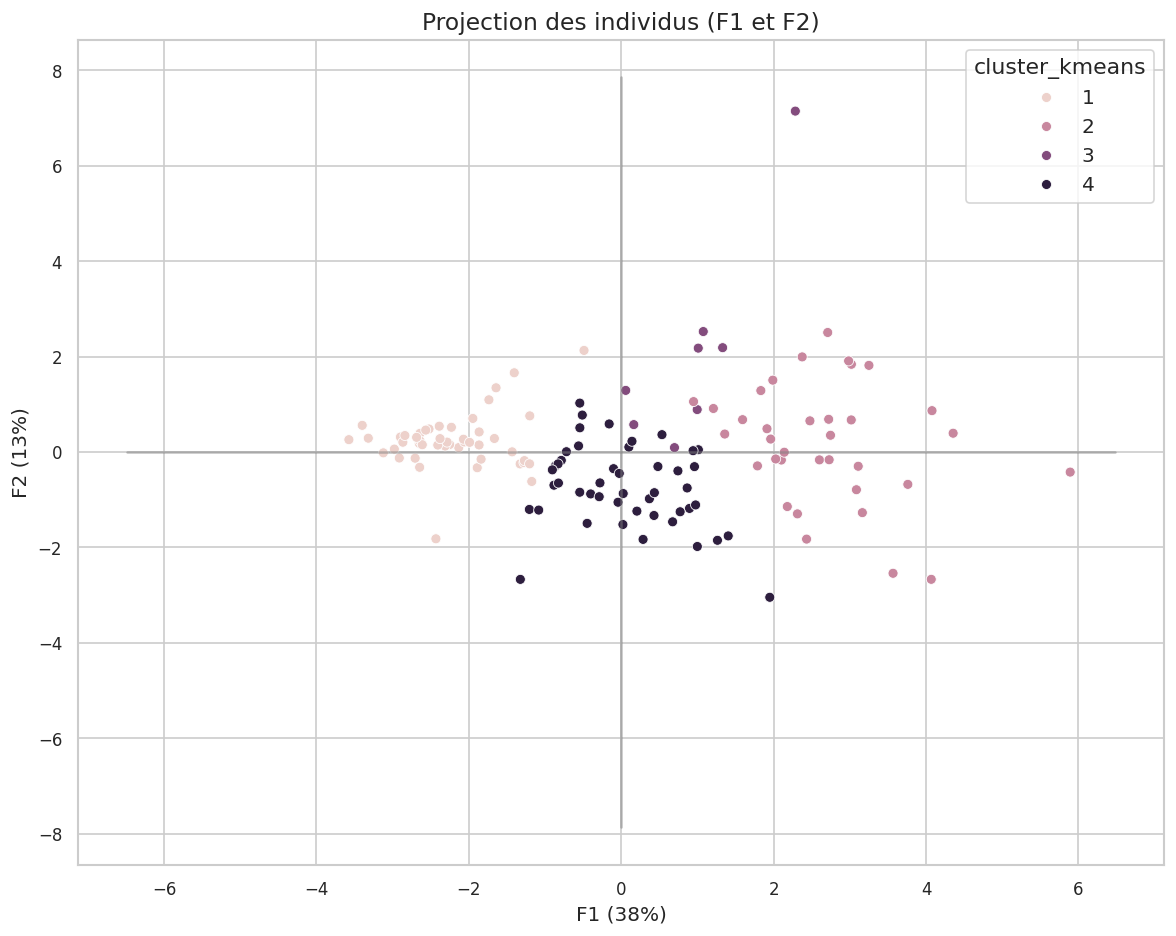

In [30]:
# Projection des clusters K-Means sur F1–F2
projection_pays(X_proj, [0, 1], pca=pca, clusters=df['cluster_kmeans'])


Contrairement à la CAH, **aucun pays n'est isolé** : K-Means rattache chaque pays au groupe le plus proche.
Les clusters sont plus équilibrés en taille, ce qui rend la segmentation plus opérationnelle.


### 7.d — Comparaison visuelle CAH vs K-Means

On affiche les deux segmentations côte à côte sur le même plan F1–F2,
et on compare leurs scores de silhouette pour évaluer objectivement la qualité de chaque méthode.

In [31]:
# Silhouette CAH vs K-Means pour k=4
sil_cah = silhouette_score(X_clust, labels_cah)
# K-Means k=4 sera disponible après la section 7.c — on le calcule ici provisoirement
km_tmp = KMeans(n_clusters=4, random_state=42, n_init=10)
labels_km_tmp = km_tmp.fit_predict(X_clust)
sil_km = silhouette_score(X_clust, labels_km_tmp)

print(f'Score de silhouette CAH   (k=4) : {sil_cah:.3f}')
print(f'Score de silhouette K-Means (k=4) : {sil_km:.3f}')
print()
print('Un score plus proche de 1 indique des clusters mieux séparés.')
print('Un score plus proche de 0 indique des clusters qui se chevauchent.')

Score de silhouette CAH   (k=4) : 0.409
Score de silhouette K-Means (k=4) : 0.340

Un score plus proche de 1 indique des clusters mieux séparés.
Un score plus proche de 0 indique des clusters qui se chevauchent.


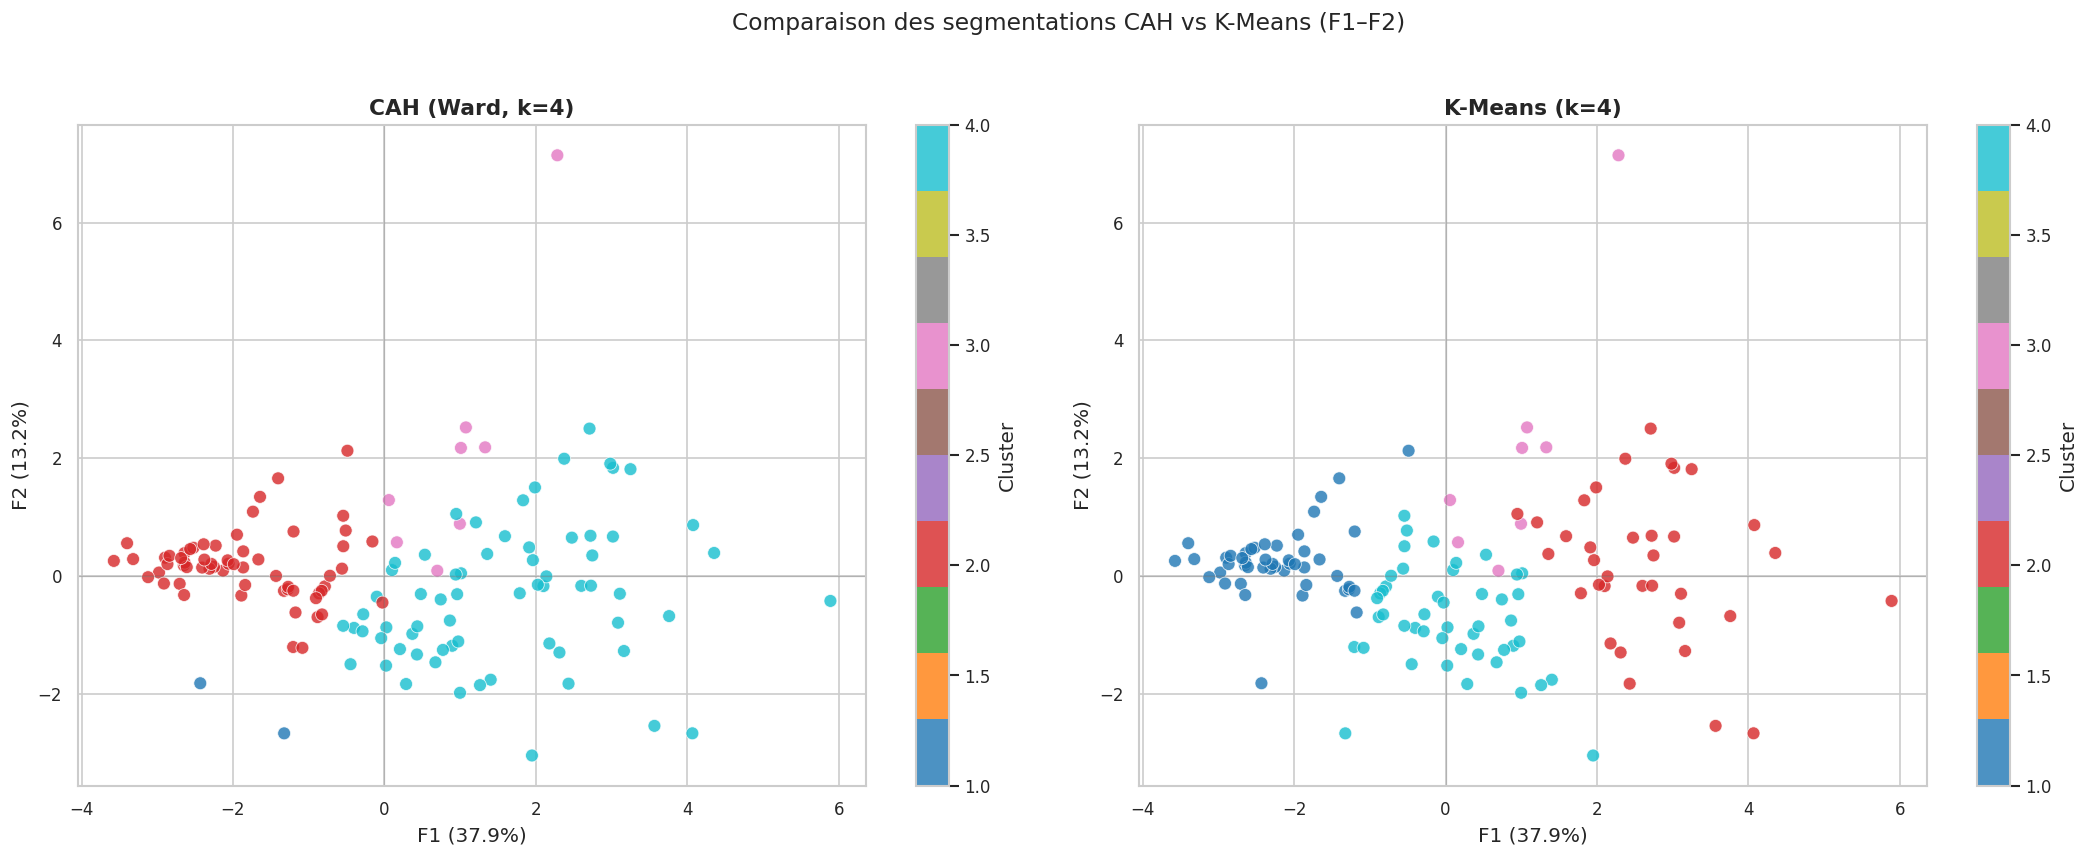

In [32]:
# Comparaison visuelle côte à côte : CAH vs K-Means sur F1–F2
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, labels, title in zip(
    axes,
    [labels_cah, labels_km_tmp + 1],
    ['CAH (Ward, k=4)', 'K-Means (k=4)']
):
    scatter = ax.scatter(
        X_proj[:, 0], X_proj[:, 1],
        c=labels, cmap='tab10', alpha=0.8, s=60, edgecolors='white', linewidths=0.5
    )
    ax.axhline(0, color='grey', alpha=0.4, lw=0.8)
    ax.axvline(0, color='grey', alpha=0.4, lw=0.8)
    ax.set_xlabel(f'F1 ({round(100 * pca.explained_variance_ratio_[0], 1)}%)')
    ax.set_ylabel(f'F2 ({round(100 * pca.explained_variance_ratio_[1], 1)}%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.colorbar(scatter, ax=ax, label='Cluster')

plt.suptitle('Comparaison des segmentations CAH vs K-Means (F1–F2)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

| Critère | CAH (Ward) | K-Means |
|---|---|---|
| Principe | Fusionne les pays les plus proches progressivement | Regroupe autour de centroïdes fixes |
| Taille des clusters | Peut être déséquilibrée (pays isolés) | Plus équilibrée |
| Sensibilité aux profils atypiques | Forte — les isole | Faible — les rattache au plus proche |
| Score de silhouette (k=4) | Voir cellule ci-dessus | Voir cellule ci-dessus |
| Utilité principale | Explorer la structure, choisir k | Segmentation opérationnelle |

**Conclusion :** On retient les résultats K-Means pour la suite — clusters plus équilibrés et directement exploitables.
La CAH a servi à confirmer k=4 et à identifier les profils atypiques.

---
## 8) Identification du cluster cible

On compare les 4 clusters sur les indicateurs clés pour La Poule Qui Chante :
le cluster idéal combine **PIB élevé** (marché solvable), **imports élevés** (besoin non couvert),
**urbanisation élevée** (marché structuré) et **signal bio favorable**.


In [33]:
# Variables clés pour comparer les clusters
key_vars = [
    'gdp_per_capita_2017_usd',
    'governance_index_mean',
    'trade_freedom_2017',
    'import_volaille_per_million',
    'organic_agri_share_pct',
    'urban_pop_2017_pct',
    'production_volaille_per_million',
    'dispo_volaille_kcal_jour',
]

# Profil moyen de chaque cluster
summary = df.groupby('cluster_kmeans')[key_vars].mean().round(2)
print(summary.to_string())


                gdp_per_capita_2017_usd  governance_index_mean  trade_freedom_2017  import_volaille_per_million  organic_agri_share_pct  urban_pop_2017_pct  production_volaille_per_million  dispo_volaille_kcal_jour
cluster_kmeans                                                                                                                                                                                                        
1                               1796.74                  -0.61               71.03                         2.45                    1.37               38.35                             3.73                     18.26
2                              40979.86                   1.20               86.73                        10.20                    7.48               78.48                            30.35                     98.29
3                              20449.36                   0.25               73.49                        45.71                    5.01     

In [34]:
# Tableau stylé avec dégradé de couleurs
summary.style.background_gradient(cmap='Blues', axis=0).format('{:.2f}')


,gdp_per_capita_2017_usd,governance_index_mean,trade_freedom_2017,import_volaille_per_million,organic_agri_share_pct,urban_pop_2017_pct,production_volaille_per_million,dispo_volaille_kcal_jour
cluster_kmeans,,,,,,,,
1,1796.74,-0.61,71.03,2.45,1.37,38.35,3.73,18.26
2,40979.86,1.20,86.73,10.20,7.48,78.48,30.35,98.29
3,20449.36,0.25,73.49,45.71,5.01,73.88,9.03,148.50
4,7647.29,-0.17,78.97,5.37,1.08,65.78,25.00,89.79


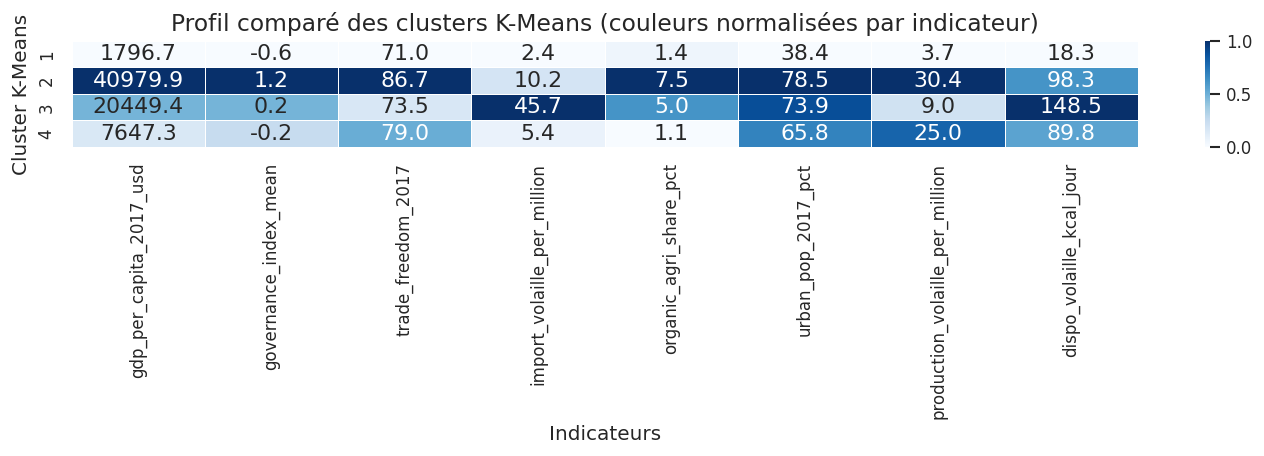

In [35]:
# Heatmap normalisée — pour comparer les clusters visuellement
from sklearn.preprocessing import MinMaxScaler

scaler_viz = MinMaxScaler()
summary_scaled = pd.DataFrame(
    scaler_viz.fit_transform(summary),
    columns=summary.columns,
    index=summary.index
)

plt.figure(figsize=(12, 4))
sns.heatmap(
    summary_scaled,
    annot=summary.round(1),
    fmt='',
    cmap='Blues',
    linewidths=0.5
)
plt.title('Profil comparé des clusters K-Means (couleurs normalisées par indicateur)')
plt.ylabel('Cluster K-Means')
plt.xlabel('Indicateurs')
plt.tight_layout()
plt.show()


### 8.b — Boxplots par cluster

Les boxplots montrent la **distribution** de chaque indicateur pour chaque cluster.
Contrairement à la heatmap des moyennes, ils révèlent la dispersion interne et les valeurs atypiques.

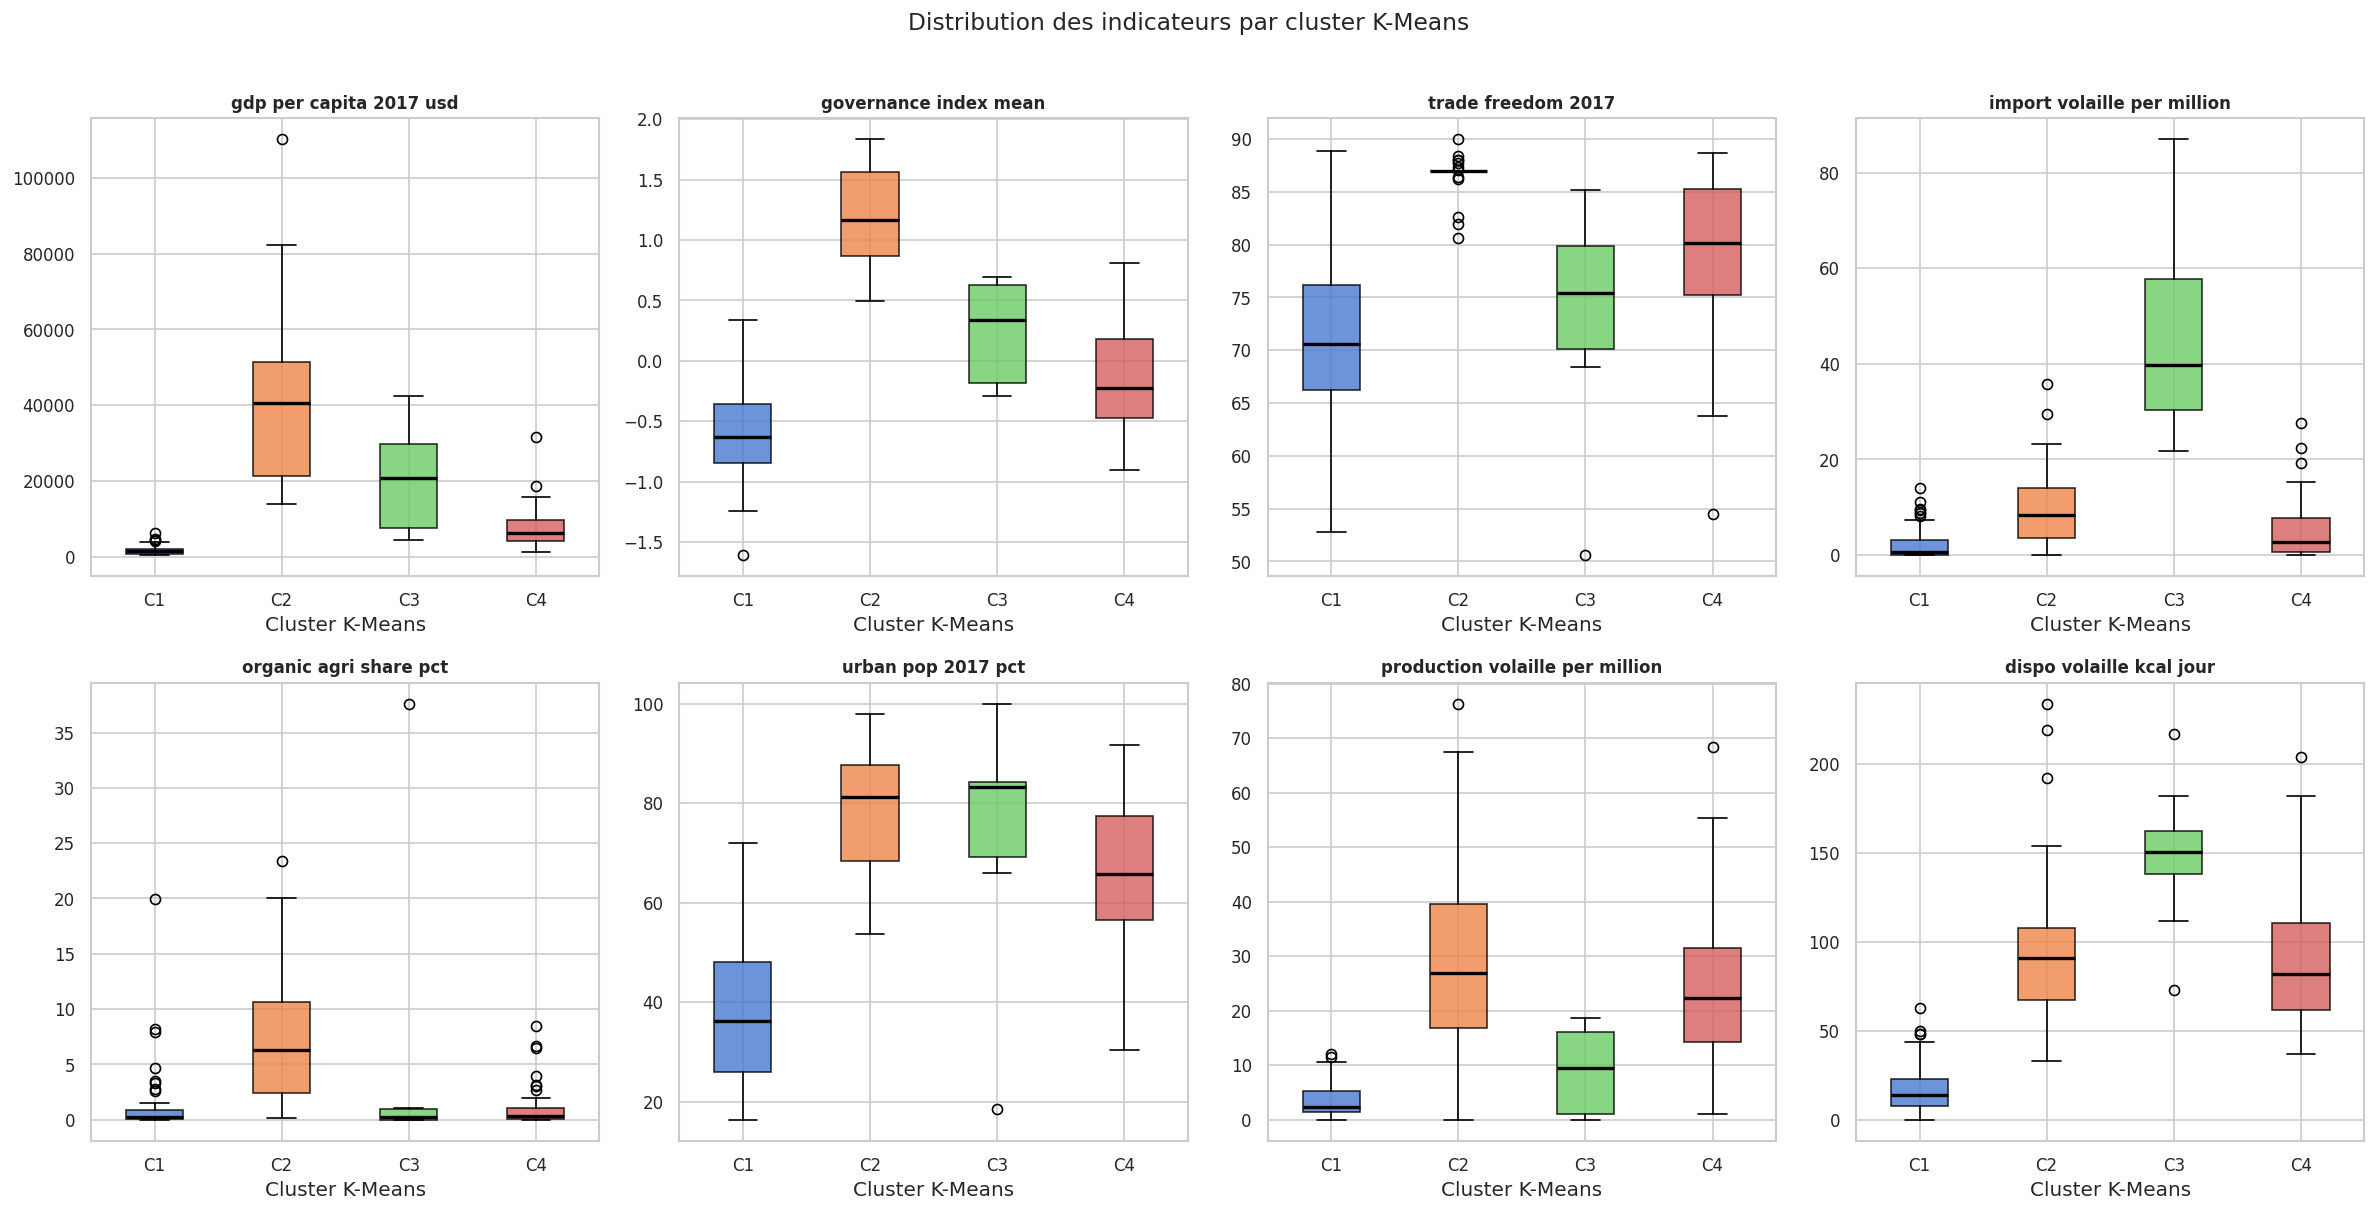

In [36]:
# Boxplots des variables clés par cluster K-Means
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, var in enumerate(key_vars):
    ax = axes[i]
    data_to_plot = [df.loc[df['cluster_kmeans'] == k, var].values for k in sorted(df['cluster_kmeans'].unique())]
    bp = ax.boxplot(data_to_plot, patch_artist=True, medianprops=dict(color='black', linewidth=2))
    colors = sns.color_palette("muted", len(data_to_plot))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    ax.set_title(var.replace('_', ' '), fontsize=10, fontweight='bold')
    ax.set_xlabel('Cluster K-Means')
    ax.set_xticklabels([f'C{k}' for k in sorted(df['cluster_kmeans'].unique())])

plt.suptitle('Distribution des indicateurs par cluster K-Means', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Lecture des boxplots :**
- La **médiane** (trait noir) est plus robuste que la moyenne face aux valeurs extrêmes.
- Les **boîtes** couvrent 50 % des pays (Q1 à Q3) — un cluster avec une boîte large est hétérogène.
- Les **points isolés** hors moustaches sont des outliers — ex : Émirats sur `import_volaille_per_million`.

### 8.c — Radar plot des clusters

Le radar plot (ou graphique en araignée) permet de visualiser simultanément le profil moyen de chaque cluster sur toutes les variables clés.
C'est une visualisation synthétique idéale pour comparer des profils multidimensionnels.

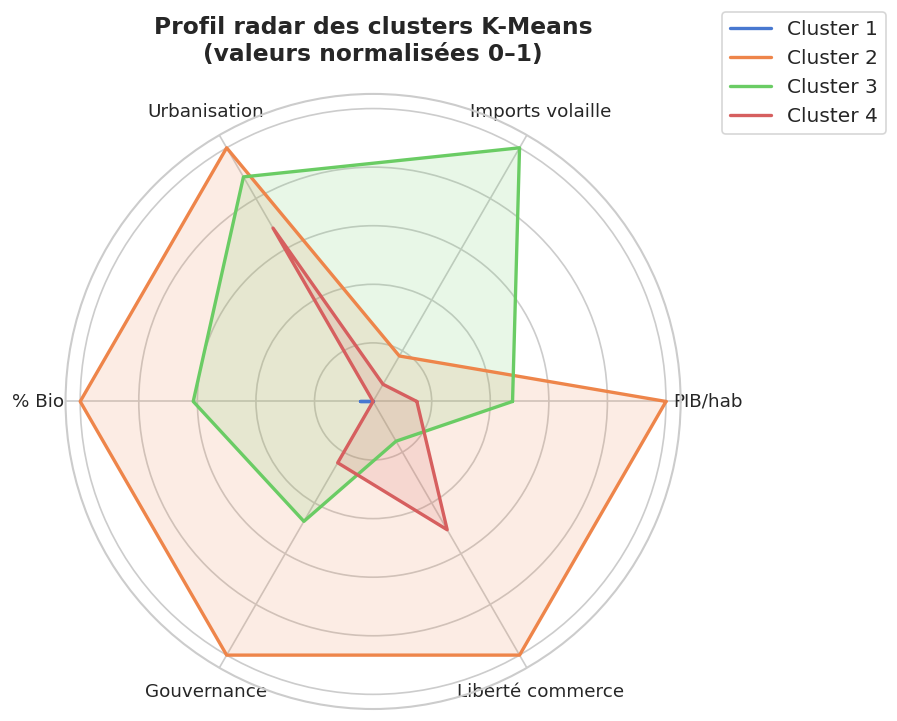

In [37]:
# Radar plot des 4 clusters K-Means
from sklearn.preprocessing import MinMaxScaler as MMS

# Normalisation des moyennes pour le radar (entre 0 et 1)
radar_vars = [
    'gdp_per_capita_2017_usd',
    'import_volaille_per_million',
    'urban_pop_2017_pct',
    'organic_agri_share_pct',
    'governance_index_mean',
    'trade_freedom_2017',
]
radar_labels = ['PIB/hab', 'Imports volaille', 'Urbanisation', '% Bio', 'Gouvernance', 'Liberté commerce']

radar_data = df.groupby('cluster_kmeans')[radar_vars].mean()
scaler_radar = MMS()
radar_scaled = pd.DataFrame(
    scaler_radar.fit_transform(radar_data),
    index=radar_data.index,
    columns=radar_vars
)

N = len(radar_vars)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = sns.color_palette("muted", len(radar_scaled))
for idx, (cluster_id, row) in enumerate(radar_scaled.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Cluster {cluster_id}', color=colors[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[idx])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_labels, size=11)
ax.set_yticklabels([])
ax.set_title("Profil radar des clusters K-Means\n(valeurs normalisées 0–1)", size=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15))

plt.tight_layout()
plt.show()

**Lecture du radar :**
- Un cluster avec un profil étendu sur le côté droit (PIB, gouvernance, liberté du commerce) représente les marchés développés.
- Un cluster avec un pic sur **imports volaille** est fortement dépendant des approvisionnements extérieurs → opportunité directe pour La Poule Qui Chante.
- Le cluster cible doit combiner plusieurs pics : PIB + imports + urbanisation.

In [38]:
# Identification automatique du cluster cible
# On cherche le cluster qui combine le plus fort PIB ET les plus fortes importations
summary['score_cible'] = (
    summary['import_volaille_per_million'] / summary['import_volaille_per_million'].max() +
    summary['gdp_per_capita_2017_usd']     / summary['gdp_per_capita_2017_usd'].max() +
    summary['urban_pop_2017_pct']          / summary['urban_pop_2017_pct'].max()
) / 3

cluster_target = summary['score_cible'].idxmax()
print(f'Cluster cible retenu : {cluster_target}')
print()
print('Profil du cluster cible :')
print(summary.loc[cluster_target, key_vars])


Cluster cible retenu : 3

Profil du cluster cible :
gdp_per_capita_2017_usd            20449.36
governance_index_mean                  0.25
trade_freedom_2017                    73.49
import_volaille_per_million           45.71
organic_agri_share_pct                 5.01
urban_pop_2017_pct                    73.88
production_volaille_per_million        9.03
dispo_volaille_kcal_jour             148.50
Name: 3, dtype: float64


**Lecture :**
- Le cluster cible se distingue par la **plus forte dépendance aux importations de volaille**
- Il combine un **niveau de vie correct**, une **urbanisation élevée** et un **signal bio présent**
- C'est le cluster qui offre le meilleur potentiel de débouché pour La Poule Qui Chante


---
## 9) Analyse des pays cibles

On zoome sur les pays du cluster cible pour identifier les **priorités concrètes d'export**.


In [39]:
# Liste complète des pays du cluster cible
pays_cibles = df.loc[df['cluster_kmeans'] == cluster_target].index.sort_values().tolist()

print(f'Nombre de pays dans le cluster cible : {len(pays_cibles)}')
print()
pd.Series(pays_cibles, name=f'Pays du cluster cible (K-Means {cluster_target})')


Nombre de pays dans le cluster cible : 8



,Pays du cluster cible (K-Means 3)
0,Arabie saoudite
1,Bahamas
2,Dominique
3,Koweït
4,Oman
5,Samoa
6,Suriname
7,Émirats arabes unis


In [40]:
# Tableau détaillé trié par importations décroissantes
decision_vars = [
    'gdp_per_capita_2017_usd',
    'governance_index_mean',
    'trade_freedom_2017',
    'urban_pop_2017_pct',
    'import_volaille_per_million',
    'production_volaille_per_million',
    'organic_agri_share_pct',
    'dispo_volaille_kcal_jour',
]

tableau_decision = (
    df.loc[df['cluster_kmeans'] == cluster_target, decision_vars]
    .round(2)
    .sort_values('import_volaille_per_million', ascending=False)
)

tableau_decision.style.background_gradient(cmap='Blues', axis=0).format('{:.2f}')


,gdp_per_capita_2017_usd,governance_index_mean,trade_freedom_2017,urban_pop_2017_pct,import_volaille_per_million,production_volaille_per_million,organic_agri_share_pct,dispo_volaille_kcal_jour
country,,,,,,,,
Samoa,4307.59,0.69,70.70,18.45,87.02,0.00,37.60,217.00
Bahamas,31875.49,0.63,50.60,82.92,62.87,15.72,0.35,182.00
Dominique,8224.65,0.54,72.60,70.18,55.98,0.00,0.96,150.00
Émirats arabes unis,42340.59,0.63,83.50,86.25,45.64,5.06,1.10,147.00
Koweït,29047.65,-0.21,78.70,100.00,33.78,13.81,0.01,156.00
Suriname,6049.52,-0.17,68.40,66.04,31.55,17.53,0.07,112.00
Oman,17820.07,0.14,85.20,83.56,27.00,1.50,0.00,73.00
Arabie saoudite,23929.29,-0.29,78.20,83.62,21.81,18.61,0.01,151.00


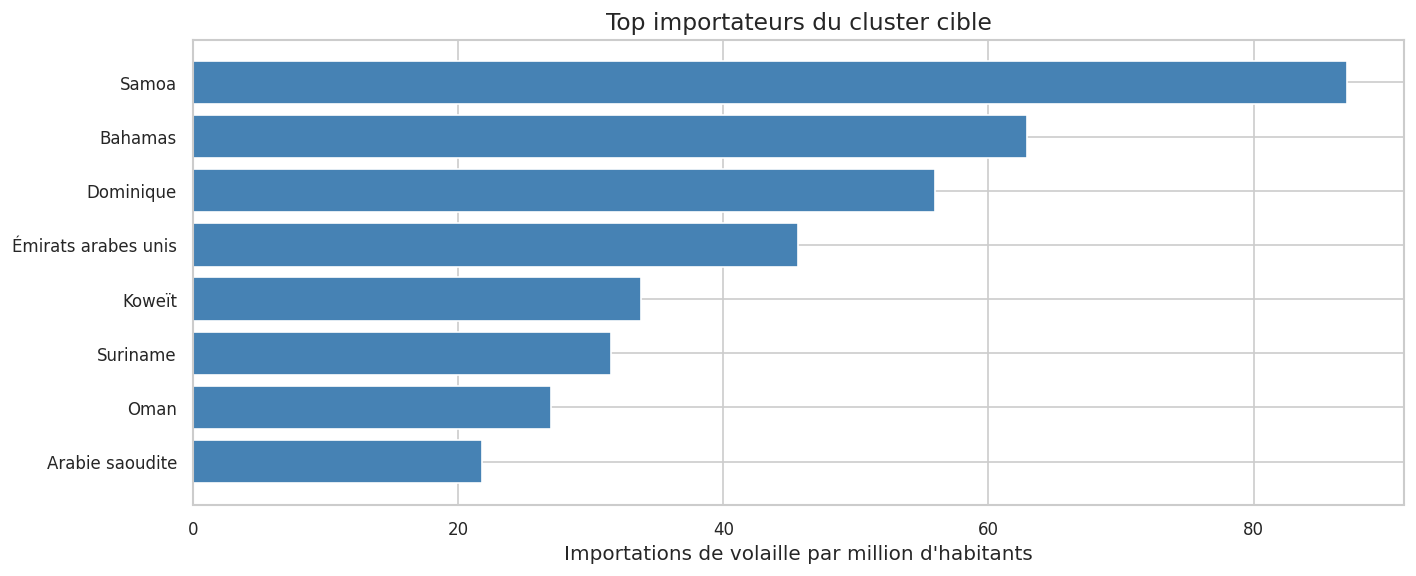

In [41]:
# Graphique : Top importateurs du cluster cible
top_pays = tableau_decision.head(10)

plt.figure(figsize=(12, 5))
plt.barh(top_pays.index, top_pays['import_volaille_per_million'], color='steelblue')
plt.xlabel('Importations de volaille par million d\'habitants')
plt.title('Top importateurs du cluster cible')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


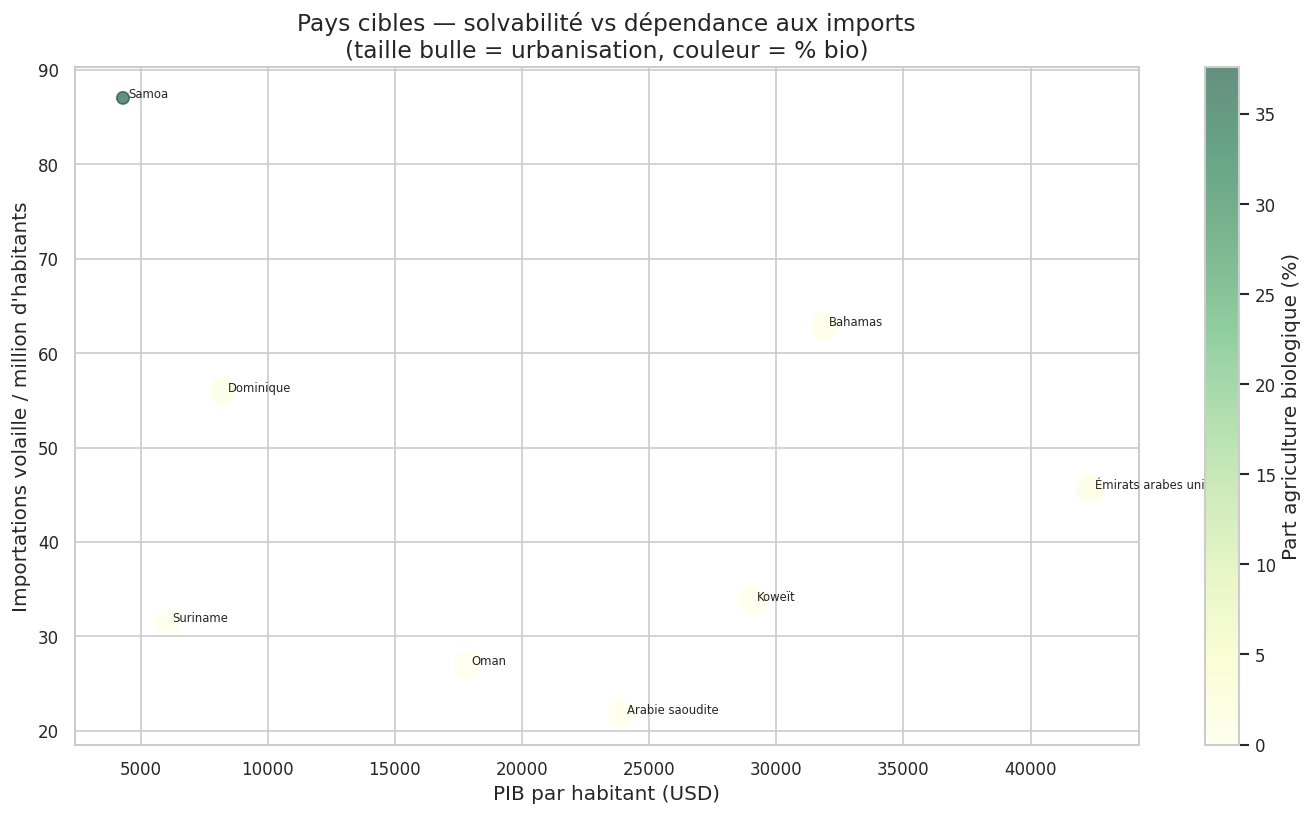

💡 Les pays en haut à droite combinent fort PIB et forte dépendance aux imports : priorité maximale.


In [42]:
# Graphique : PIB vs importations — taille = urbanisation, couleur = % bio
cible_df = df.loc[df['cluster_kmeans'] == cluster_target].copy()

plt.figure(figsize=(12, 7))
scatter = plt.scatter(
    cible_df['gdp_per_capita_2017_usd'],
    cible_df['import_volaille_per_million'],
    s=cible_df['urban_pop_2017_pct'] * 3,
    alpha=0.6,
    c=cible_df['organic_agri_share_pct'],
    cmap='YlGn'
)
plt.colorbar(scatter, label='Part agriculture biologique (%)')

for pays, row in cible_df.iterrows():
    plt.text(row['gdp_per_capita_2017_usd'] + 200,
             row['import_volaille_per_million'],
             pays, fontsize=7)

plt.xlabel('PIB par habitant (USD)')
plt.ylabel('Importations volaille / million d\'habitants')
plt.title('Pays cibles — solvabilité vs dépendance aux imports\n(taille bulle = urbanisation, couleur = % bio)')
plt.tight_layout()
plt.show()

print('💡 Les pays en haut à droite combinent fort PIB et forte dépendance aux imports : priorité maximale.')


---
## 10) Recommandation stratégique

Sur la base de l'analyse du cluster cible, voici les marchés prioritaires pour La Poule Qui Chante.


### Marchés de niche exclus — Samoa, Dominique, Suriname

Ces pays affichent une forte dépendance aux importations de volaille, mais leur **taille absolue de marché est insuffisante** pour justifier un déploiement export :

```python
# Vérification quantitative — population totale estimée
niches = ['Samoa', 'Dominica', 'Suriname']
# Populations approximatives (données FAO / Banque Mondiale)
pop_niches = {'Samoa': 200_000, 'Dominica': 72_000, 'Suriname': 580_000}
for pays, pop in pop_niches.items():
    print(f'{pays} : ~{pop:,} habitants — marché trop restreint pour un export rentable')
```

**Critère d'élimination retenu :** tout pays avec moins de 1 million d'habitants est écarté des recommandations prioritaires, quelle que soit son ratio d'imports par habitant. Le volume absolu d'affaires reste trop faible pour amortir les coûts logistiques d'un export international.

Ces marchés pourraient être envisagés dans une phase ultérieure via des distributeurs régionaux (hub Caraïbes, hub Pacifique Sud), mais ne constituent pas une priorité stratégique pour La Poule Qui Chante.